In [11]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path

# Add project root to path to import data_utils
project_root = os.path.abspath('..')  # Assuming notebook is in project root
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import our custom data utilities
from utils.data_utils import DataPathManager, PviDataset, PviBatchServer, load_subjects

# Configuration
FRAME_SIZE = 50  # 50 samples = 1 second of BP data
plt.style.use('default')

print("Imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"Project root: {project_root}")


Imports successful!
PyTorch version: 2.6.0+cu124
Project root: /home/lucas_takanori/phd


In [12]:
# Step 1: Initialize DataPathManager and load dataset
print("="*60)
print("STEP 1: Loading Data with data_utils.py")
print("="*60)

# Method 1: Using DataPathManager (recommended approach)
print("\n--- Using DataPathManager ---")
path_manager = DataPathManager(
    subject="subject001",
    session="baseline", 
    root="/home/lucas_takanori/phd/data"  # Update this path as needed
)

print(f"\nData file path: {path_manager._h5_path}")
print(f"File exists: {path_manager._h5_path.exists()}")

# Load the dataset
print("\n--- Loading PviDataset ---")
dataset = PviDataset(path_manager._h5_path)

# Print dataset information
dataset._print_init()


STEP 1: Loading Data with data_utils.py

--- Using DataPathManager ---
Looking for data file at: /home/lucas_takanori/phd/data/subject001_baseline_masked.h5
DataPathManager successfully initiated!

Data file path: /home/lucas_takanori/phd/data/subject001_baseline_masked.h5
File exists: True

--- Loading PviDataset ---
Using Torch version: 2.6.0+cu124
Data directory set to:
	/home/lucas_takanori/phd/data
Found HDF5 data: 'subject001_baseline_masked.h5'
Loading metadata...
	 ...Done!
PviDataset successfully initiated!
Loading raw data...
	 ...Done! (3.33 seconds)
Number of periods: 867
Stacking samples (400 total):
	 ...100/400 samples
	 ...200/400 samples
	 ...300/400 samples
	 ...400/400 samples
	 ...Done! (3.67 seconds)
Number of samples: 400
Finish loading PviDataset!

=====PviDataset=====
Dataset name: subject001_baseline_masked.h5
Number of samples: 400
Dataset keys: ['ecg', 'bp', 'pviLP', 'pviHP', 'stats']
Dataset shape:
	 ecg.signal: (50,)
	 bp.signal: (50,)
	 pviLP.signal: (500,

In [13]:
# Step 2: Analyze the data structure and compare with direct HDF5 loading
print("="*60)
print("STEP 2: Analyzing Data Structure - COMPARISON")
print("="*60)

# Get a sample to understand the data structure
sample = dataset[0]  # First sample
print(f"Sample keys: {list(sample.keys())}")

# Analyze BP signal structure
bp_signal = sample['bp']['signal']
print(f"\nBP Signal Analysis (data_utils approach):")
print(f"  Type: {type(bp_signal)}")
print(f"  Shape: {bp_signal.shape}")
print(f"  Data type: {bp_signal.dtype}")
print(f"  Min value: {bp_signal.min():.2f} mmHg")
print(f"  Max value: {bp_signal.max():.2f} mmHg")
print(f"  Mean value: {bp_signal.mean():.2f} mmHg")

# IMPORTANT DISCOVERY: Each sample is already exactly 50 samples (1 second)!
print(f"\n🔍 KEY INSIGHT:")
print(f"  Each 'sample' in data_utils is already a 1-second BP frame!")
print(f"  Total samples in dataset: {len(dataset)} (each = 1 second of BP data)")
print(f"  This is different from direct HDF5 loading!")

# Compare with direct HDF5 loading
print(f"\n📊 COMPARISON WITH DIRECT HDF5:")
import h5py
with h5py.File(path_manager._h5_path, 'r') as f:
    raw_bp_data = f['data']['bp']['signal'][:]
    print(f"  Direct HDF5 shape: {raw_bp_data.shape} → {raw_bp_data.shape[0]} batches × {raw_bp_data.shape[1]} samples")
    print(f"  Direct HDF5 frames per batch: {raw_bp_data.shape[1] // FRAME_SIZE}")
    print(f"  Direct HDF5 total frames: {raw_bp_data.shape[0] * (raw_bp_data.shape[1] // FRAME_SIZE)}")
    print(f"  data_utils samples: {len(dataset)} (pre-segmented)")

# Analyze PVI image structure (if available)
if 'pviHP' in sample and 'img' in sample['pviHP']:
    pvi_img = sample['pviHP']['img']
    print(f"\nPVI Image Analysis:")
    print(f"  Shape: {pvi_img.shape}")
    print(f"  Data type: {pvi_img.dtype}")
    # Handle NaN values
    valid_values = pvi_img[~torch.isnan(pvi_img)]
    if len(valid_values) > 0:
        print(f"  Valid values range: [{valid_values.min():.6f}, {valid_values.max():.6f}]")
        print(f"  NaN count: {torch.isnan(pvi_img).sum().item()}/{pvi_img.numel()}")
    else:
        print(f"  All values are NaN")

print(f"\n✅ CONCLUSION: data_utils pre-segments the data into 1-second frames")
print(f"   Each dataset[i] is equivalent to one BP frame from direct loading!")


STEP 2: Analyzing Data Structure - COMPARISON
Sample keys: ['ecg', 'bp', 'pviLP', 'pviHP', 'stats']

BP Signal Analysis (data_utils approach):
  Type: <class 'torch.Tensor'>
  Shape: torch.Size([50])
  Data type: torch.float32
  Min value: 42.16 mmHg
  Max value: 101.02 mmHg
  Mean value: 64.59 mmHg

🔍 KEY INSIGHT:
  Each 'sample' in data_utils is already a 1-second BP frame!
  Total samples in dataset: 400 (each = 1 second of BP data)
  This is different from direct HDF5 loading!

📊 COMPARISON WITH DIRECT HDF5:
  Direct HDF5 shape: (50, 867) → 50 batches × 867 samples
  Direct HDF5 frames per batch: 17
  Direct HDF5 total frames: 850
  data_utils samples: 400 (pre-segmented)

PVI Image Analysis:
  Shape: torch.Size([32, 32, 500])
  Data type: torch.float32
  Valid values range: [-0.121771, 0.127784]
  NaN count: 84000/512000

✅ CONCLUSION: data_utils pre-segments the data into 1-second frames
   Each dataset[i] is equivalent to one BP frame from direct loading!


STEP 3: CORRECTED BP Frame Plotting
🔧 CORRECTED APPROACH (data_utils):
Each sample is already a 1-second BP frame


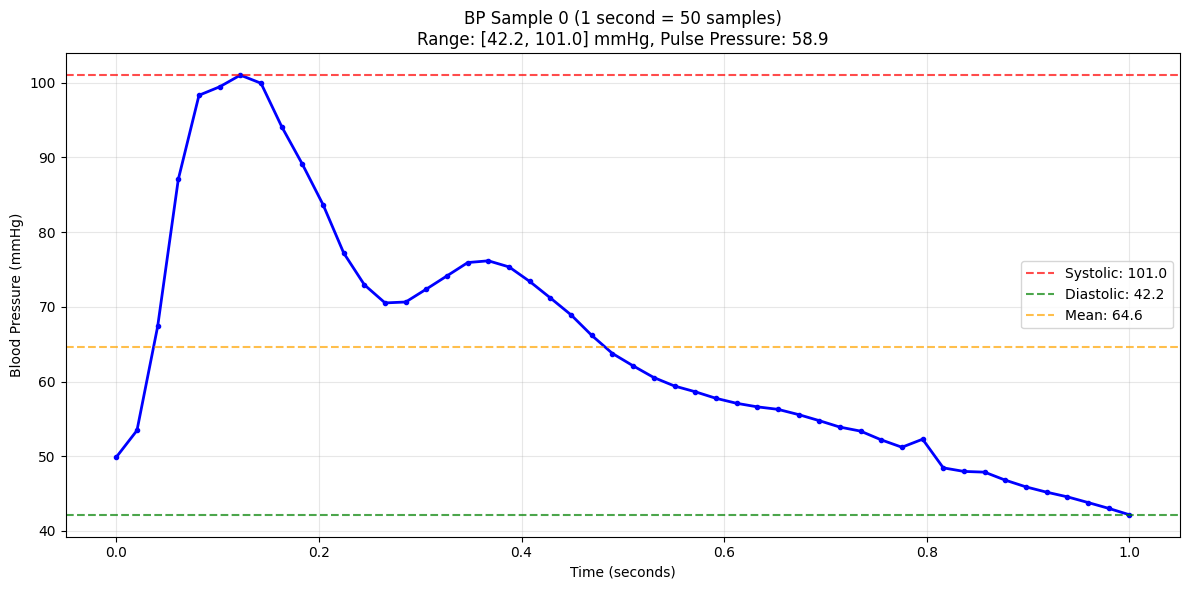

BP Sample 0 Statistics:
  Systolic: 101.0 mmHg
  Diastolic: 42.2 mmHg
  Mean BP: 64.6 mmHg
  Pulse Pressure: 58.9 mmHg
  Standard Deviation: 16.42 mmHg
  Sample length: 50 points

📊 COMPARISON WITH DIRECT HDF5 APPROACH:
Direct HDF5 approach (for comparison):


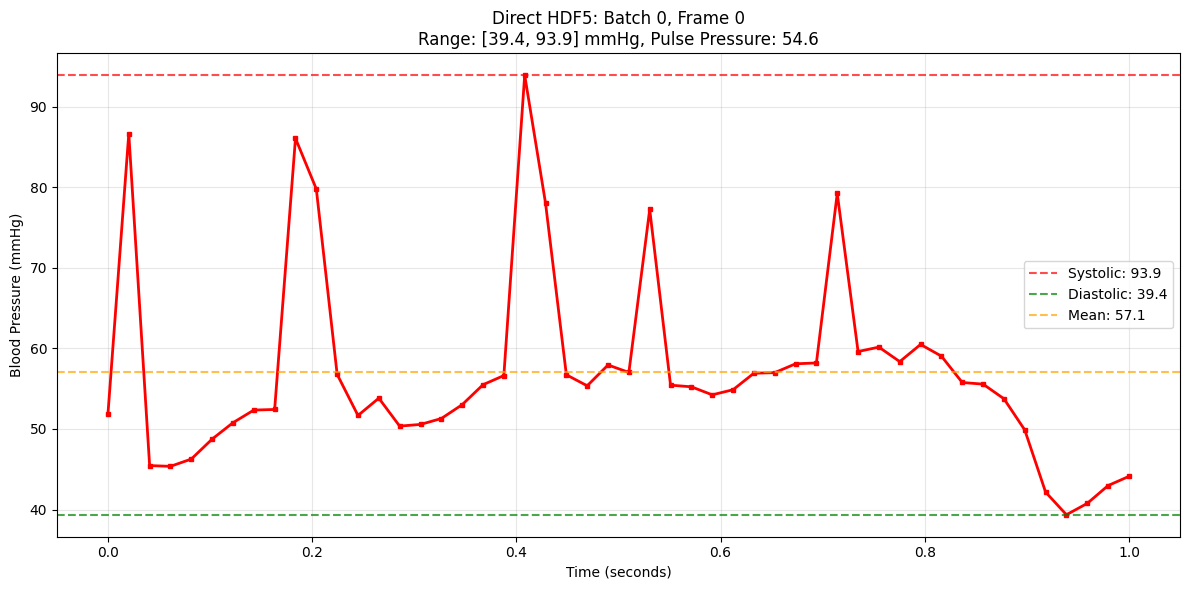

Direct HDF5 Frame 0 from Batch 0:
  Systolic: 93.9 mmHg
  Diastolic: 39.4 mmHg
  Mean BP: 57.1 mmHg
  Pulse Pressure: 54.6 mmHg


In [14]:
# CORRECTED: Each sample in data_utils IS already a complete BP frame!
def plot_bp_sample_corrected(dataset, sample_idx=0, figsize=(12, 6)):
    """Plot a BP sample (which is already a complete 1-second frame) from data_utils"""
    
    # Get the sample
    if sample_idx >= len(dataset):
        print(f"Sample index {sample_idx} out of bounds. Max: {len(dataset)-1}")
        return None
    
    sample = dataset[sample_idx]
    bp_signal = sample['bp']['signal']  # This is already exactly 50 samples (1 second)
    
    # Convert to numpy if it's a tensor
    if isinstance(bp_signal, torch.Tensor):
        bp_signal = bp_signal.numpy()
    
    # Create time axis (0 to 1 second)
    time_axis = np.linspace(0, 1, len(bp_signal))
    
    # Create the plot
    plt.figure(figsize=figsize)
    plt.plot(time_axis, bp_signal, 'b-', linewidth=2, marker='o', markersize=3)
    plt.grid(True, alpha=0.3)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Blood Pressure (mmHg)')
    
    # Calculate statistics
    systolic = np.max(bp_signal)
    diastolic = np.min(bp_signal)
    mean_bp = np.mean(bp_signal)
    
    # Add reference lines
    plt.axhline(y=systolic, color='red', linestyle='--', alpha=0.7, label=f'Systolic: {systolic:.1f}')
    plt.axhline(y=diastolic, color='green', linestyle='--', alpha=0.7, label=f'Diastolic: {diastolic:.1f}')
    plt.axhline(y=mean_bp, color='orange', linestyle='--', alpha=0.7, label=f'Mean: {mean_bp:.1f}')
    
    plt.title(f'BP Sample {sample_idx} (1 second = {len(bp_signal)} samples)\n'
              f'Range: [{diastolic:.1f}, {systolic:.1f}] mmHg, Pulse Pressure: {systolic-diastolic:.1f}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"BP Sample {sample_idx} Statistics:")
    print(f"  Systolic: {systolic:.1f} mmHg")
    print(f"  Diastolic: {diastolic:.1f} mmHg") 
    print(f"  Mean BP: {mean_bp:.1f} mmHg")
    print(f"  Pulse Pressure: {systolic-diastolic:.1f} mmHg")
    print(f"  Standard Deviation: {np.std(bp_signal):.2f} mmHg")
    print(f"  Sample length: {len(bp_signal)} points")
    
    return bp_signal

# COMPARISON: Plot using both approaches
print("="*60)
print("STEP 3: CORRECTED BP Frame Plotting")
print("="*60)

print("🔧 CORRECTED APPROACH (data_utils):")
print("Each sample is already a 1-second BP frame")
bp_sample = plot_bp_sample_corrected(dataset, sample_idx=0)

print("\n" + "="*50)
print("📊 COMPARISON WITH DIRECT HDF5 APPROACH:")
print("="*50)

# Load and plot the same data using direct HDF5 approach for comparison
import h5py
with h5py.File(path_manager._h5_path, 'r') as f:
    raw_bp_data = f['data']['bp']['signal'][:]

# Plot equivalent frame from direct HDF5
def plot_direct_h5_frame(bp_data, batch_idx=0, frame_idx=0, figsize=(12, 6)):
    """Plot using direct HDF5 approach for comparison"""
    start_idx = frame_idx * FRAME_SIZE
    end_idx = start_idx + FRAME_SIZE
    
    if end_idx > bp_data.shape[1]:
        print(f"Frame {frame_idx} out of bounds")
        return None
        
    bp_frame = bp_data[batch_idx, start_idx:end_idx]
    time_axis = np.linspace(0, 1, FRAME_SIZE)
    
    plt.figure(figsize=figsize)
    plt.plot(time_axis, bp_frame, 'r-', linewidth=2, marker='s', markersize=3)
    plt.grid(True, alpha=0.3)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Blood Pressure (mmHg)')
    
    systolic = np.max(bp_frame)
    diastolic = np.min(bp_frame)
    mean_bp = np.mean(bp_frame)
    
    plt.axhline(y=systolic, color='red', linestyle='--', alpha=0.7, label=f'Systolic: {systolic:.1f}')
    plt.axhline(y=diastolic, color='green', linestyle='--', alpha=0.7, label=f'Diastolic: {diastolic:.1f}')
    plt.axhline(y=mean_bp, color='orange', linestyle='--', alpha=0.7, label=f'Mean: {mean_bp:.1f}')
    
    plt.title(f'Direct HDF5: Batch {batch_idx}, Frame {frame_idx}\n'
              f'Range: [{diastolic:.1f}, {systolic:.1f}] mmHg, Pulse Pressure: {systolic-diastolic:.1f}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"Direct HDF5 Frame {frame_idx} from Batch {batch_idx}:")
    print(f"  Systolic: {systolic:.1f} mmHg")
    print(f"  Diastolic: {diastolic:.1f} mmHg") 
    print(f"  Mean BP: {mean_bp:.1f} mmHg")
    print(f"  Pulse Pressure: {systolic-diastolic:.1f} mmHg")
    
    return bp_frame

print("Direct HDF5 approach (for comparison):")
direct_frame = plot_direct_h5_frame(raw_bp_data, batch_idx=0, frame_idx=0)


STEP 4: Multiple BP Samples Comparison
🔧 CORRECTED: Comparing different BP samples (each is 1 second)


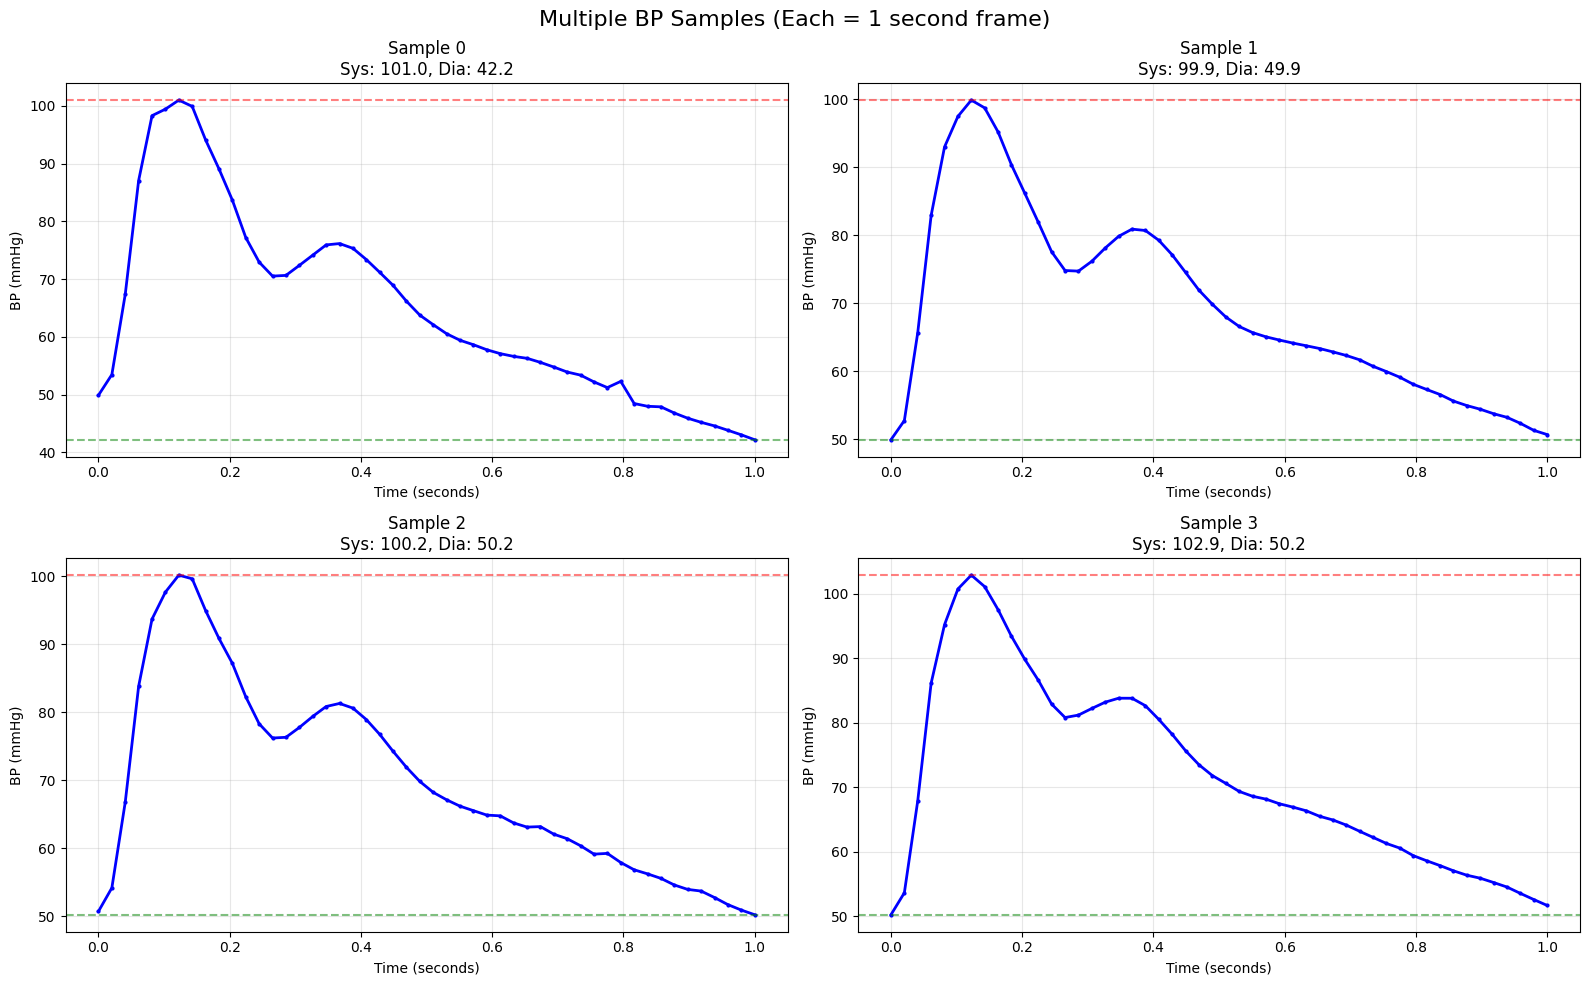


📊 COMPARISON: Multiple frames from same batch (Direct HDF5)


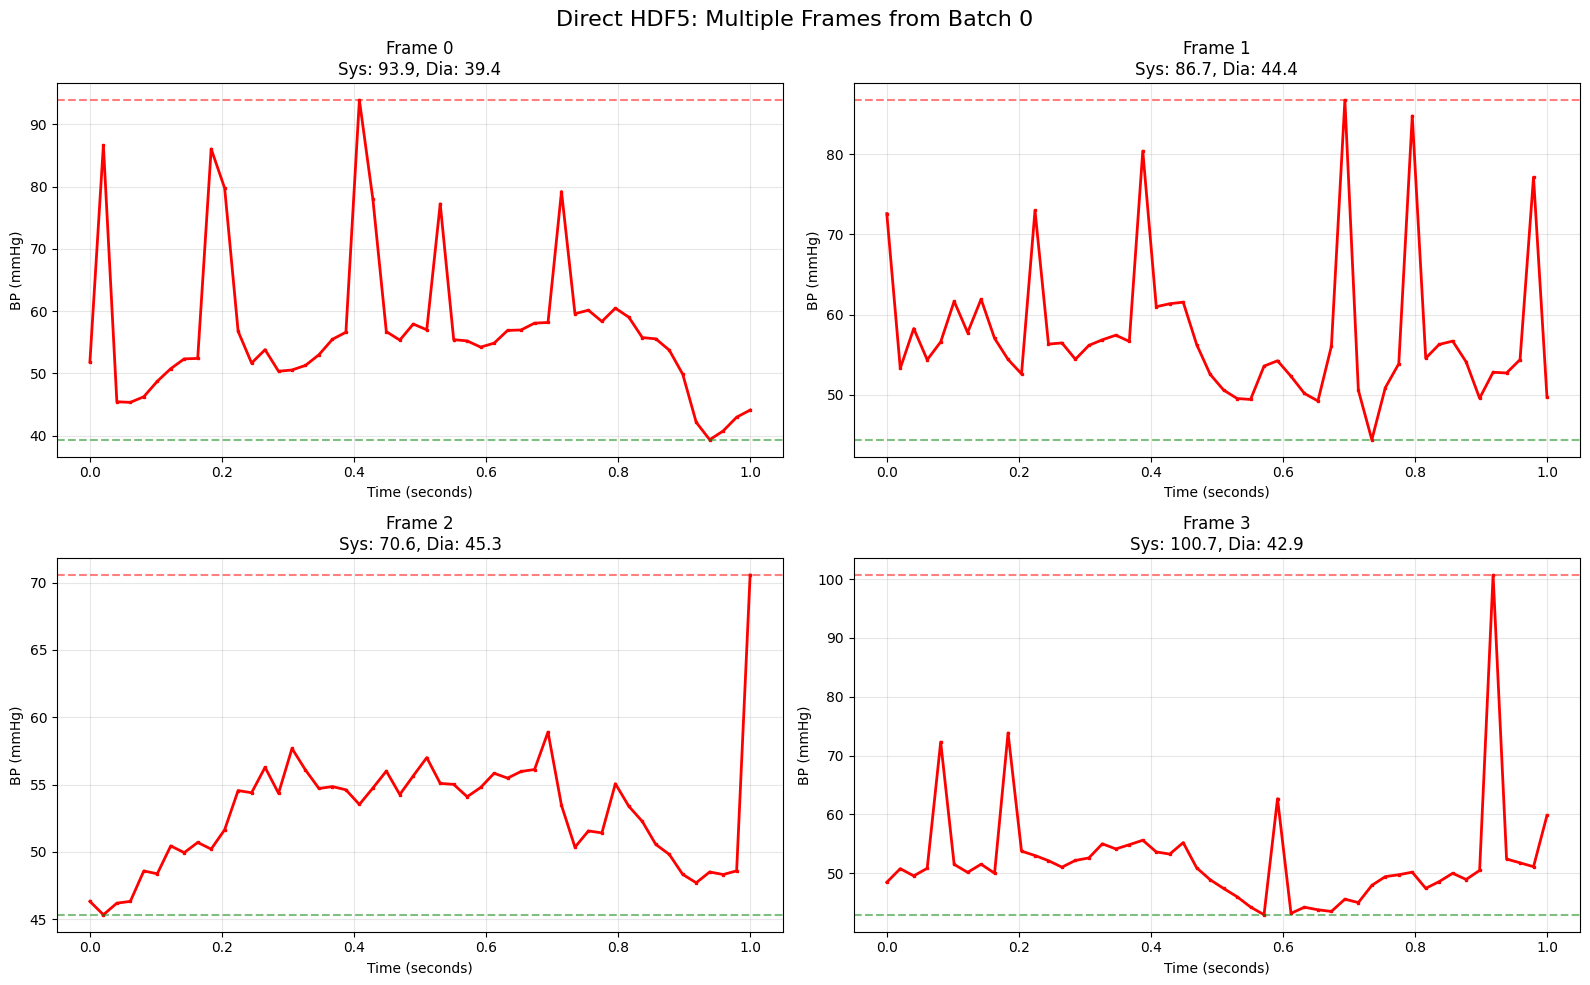

In [15]:
# CORRECTED: Plot multiple BP samples (each is already a complete frame)
def plot_multiple_bp_samples_corrected(dataset, sample_indices=[0, 1, 2, 3], figsize=(16, 10)):
    """Plot multiple BP samples (each sample is already a 1-second frame)"""
    
    n_samples = len(sample_indices)
    rows = (n_samples + 1) // 2
    cols = 2
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for i, sample_idx in enumerate(sample_indices):
        if sample_idx < len(dataset) and i < len(axes):
            sample = dataset[sample_idx]
            bp_signal = sample['bp']['signal']
            
            # Convert to numpy if tensor
            if isinstance(bp_signal, torch.Tensor):
                bp_signal = bp_signal.numpy()
            
            time_axis = np.linspace(0, 1, len(bp_signal))
            
            # Plot
            axes[i].plot(time_axis, bp_signal, 'b-', linewidth=2, marker='o', markersize=2)
            axes[i].grid(True, alpha=0.3)
            axes[i].set_xlabel('Time (seconds)')
            axes[i].set_ylabel('BP (mmHg)')
            
            # Statistics
            systolic = np.max(bp_signal)
            diastolic = np.min(bp_signal)
            axes[i].set_title(f'Sample {sample_idx}\nSys: {systolic:.1f}, Dia: {diastolic:.1f}')
            
            # Add reference lines
            axes[i].axhline(y=systolic, color='red', linestyle='--', alpha=0.5)
            axes[i].axhline(y=diastolic, color='green', linestyle='--', alpha=0.5)
        else:
            axes[i].text(0.5, 0.5, f'Sample {sample_idx}\nnot available', 
                        ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_xticks([])
            axes[i].set_yticks([])
    
    # Hide extra subplots
    for i in range(len(sample_indices), len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle(f'Multiple BP Samples (Each = 1 second frame)', fontsize=16)
    plt.tight_layout()
    plt.show()

print("="*60)
print("STEP 4: Multiple BP Samples Comparison")
print("="*60)

print("🔧 CORRECTED: Comparing different BP samples (each is 1 second)")
plot_multiple_bp_samples_corrected(dataset, sample_indices=[0, 1, 2, 3])

# For comparison, let's also show multiple frames from direct HDF5
print("\n📊 COMPARISON: Multiple frames from same batch (Direct HDF5)")
def plot_multiple_direct_frames(bp_data, batch_idx=0, frame_indices=[0, 1, 2, 3], figsize=(16, 10)):
    """Plot multiple frames from direct HDF5 for comparison"""
    
    n_frames = len(frame_indices)
    rows = (n_frames + 1) // 2
    cols = 2
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for i, frame_idx in enumerate(frame_indices):
        start_idx = frame_idx * FRAME_SIZE
        end_idx = start_idx + FRAME_SIZE
        
        if end_idx <= bp_data.shape[1] and i < len(axes):
            bp_frame = bp_data[batch_idx, start_idx:end_idx]
            time_axis = np.linspace(0, 1, FRAME_SIZE)
            
            axes[i].plot(time_axis, bp_frame, 'r-', linewidth=2, marker='s', markersize=2)
            axes[i].grid(True, alpha=0.3)
            axes[i].set_xlabel('Time (seconds)')
            axes[i].set_ylabel('BP (mmHg)')
            
            systolic = np.max(bp_frame)
            diastolic = np.min(bp_frame)
            axes[i].set_title(f'Frame {frame_idx}\nSys: {systolic:.1f}, Dia: {diastolic:.1f}')
            
            axes[i].axhline(y=systolic, color='red', linestyle='--', alpha=0.5)
            axes[i].axhline(y=diastolic, color='green', linestyle='--', alpha=0.5)
        else:
            axes[i].text(0.5, 0.5, f'Frame {frame_idx}\nnot available', 
                        ha='center', va='center', transform=axes[i].transAxes)
    
    for i in range(len(frame_indices), len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle(f'Direct HDF5: Multiple Frames from Batch {batch_idx}', fontsize=16)
    plt.tight_layout()
    plt.show()

plot_multiple_direct_frames(raw_bp_data, batch_idx=0, frame_indices=[0, 1, 2, 3])


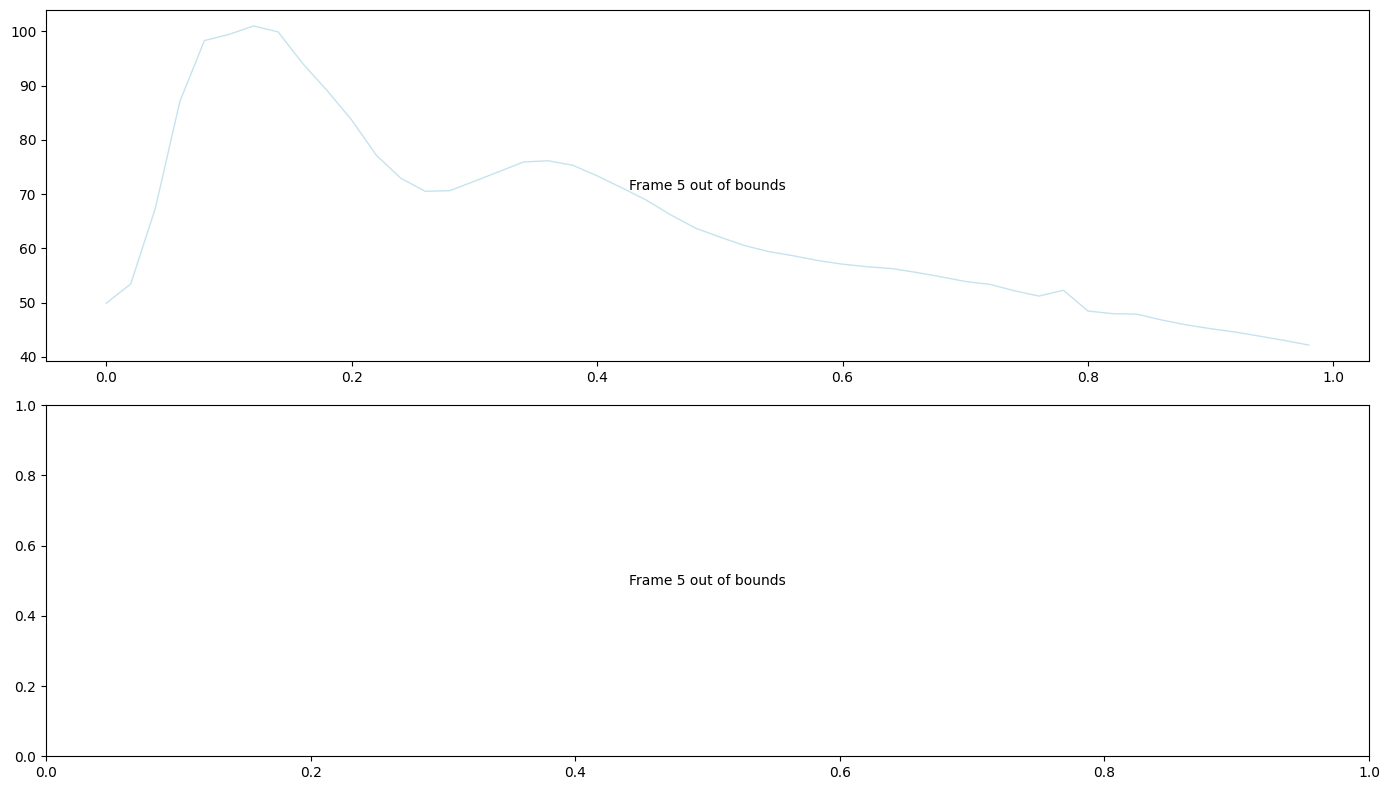

In [16]:
def plot_bp_frame_with_full_signal_context(dataset, sample_idx=0, frame_idx=5, figsize=(14, 8)):
    """Plot a BP frame with full signal context"""
    
    if sample_idx >= len(dataset):
        print(f"Sample index {sample_idx} out of bounds")
        return
    
    sample = dataset[sample_idx]
    bp_signal = sample['bp']['signal']
    
    # Convert to numpy if tensor
    if isinstance(bp_signal, torch.Tensor):
        bp_signal = bp_signal.numpy()
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize)
    
    # Plot 1: Full signal with frame highlighted
    time_full = np.arange(len(bp_signal)) / 50.0  # Convert to seconds (assuming 50 Hz)
    
    ax1.plot(time_full, bp_signal, 'lightblue', linewidth=1, alpha=0.7, label='Full BP Signal')
    
    # Highlight the target frame
    start_idx = frame_idx * FRAME_SIZE
    end_idx = start_idx + FRAME_SIZE
    
    if end_idx <= len(bp_signal):
        frame_time = np.arange(start_idx, end_idx) / 50.0
        frame_signal = bp_signal[start_idx:end_idx]
        
        ax1.plot(frame_time, frame_signal, 'red', linewidth=3, label=f'Frame {frame_idx}')
        ax1.fill_between(frame_time, frame_signal, alpha=0.3, color='red')
        
        ax1.set_xlabel('Time (seconds)')
        ax1.set_ylabel('BP (mmHg)')
        ax1.set_title(f'Full BP Signal with Frame {frame_idx} Highlighted - Sample {sample_idx}')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        # Plot 2: Detailed view of the frame
        time_axis = np.linspace(0, 1, FRAME_SIZE)
        
        ax2.plot(time_axis, frame_signal, 'blue', linewidth=3, marker='o', markersize=3)
        
        # Add statistics
        systolic = np.max(frame_signal)
        diastolic = np.min(frame_signal)
        mean_bp = np.mean(frame_signal)
        
        ax2.axhline(y=systolic, color='red', linestyle='--', alpha=0.7, label=f'Systolic: {systolic:.1f}')
        ax2.axhline(y=diastolic, color='green', linestyle='--', alpha=0.7, label=f'Diastolic: {diastolic:.1f}')
        ax2.axhline(y=mean_bp, color='orange', linestyle='--', alpha=0.7, label=f'Mean: {mean_bp:.1f}')
        
        ax2.set_xlabel('Time (seconds)')
        ax2.set_ylabel('BP (mmHg)')
        ax2.set_title(f'Detailed View: Frame {frame_idx} (1 second)')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        
        # Print statistics
        print(f"Frame {frame_idx} from Sample {sample_idx}:")
        print(f"  Time range: {frame_time[0]:.2f} - {frame_time[-1]:.2f} seconds")
        print(f"  Systolic: {systolic:.1f} mmHg")
        print(f"  Diastolic: {diastolic:.1f} mmHg")
        print(f"  Pulse Pressure: {systolic - diastolic:.1f} mmHg")
        print(f"  Total signal length: {len(bp_signal)} samples ({len(bp_signal)/50.0:.1f} seconds)")
    else:
        ax1.text(0.5, 0.5, f'Frame {frame_idx} out of bounds', 
                ha='center', va='center', transform=ax1.transAxes)
        ax2.text(0.5, 0.5, f'Frame {frame_idx} out of bounds', 
                ha='center', va='center', transform=ax2.transAxes)
    
    plt.tight_layout()
    plt.show()

# Plot frame with full context
plot_bp_frame_with_full_signal_context(dataset, sample_idx=0, frame_idx=5)


In [17]:
# Step 4: Using PviBatchServer for batch processing
print("="*60)
print("STEP 4: Using PviBatchServer")
print("="*60)

# Create a batch server for easier data handling
batch_server = PviBatchServer(
    dataset=dataset,
    input_type="signal",  # We want signal data as input
    output_type="minmax"  # We want min/max as output (systolic/diastolic)
)

# Set up data loaders
batch_server.set_loader_params(
    batch_size=4,
    test_size=0.2,
    random_state=42
)

# Get data loaders
train_loader, test_loader = batch_server.get_loaders()

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

# Get a batch and analyze it
print("\n--- Analyzing a batch ---")
batch = next(iter(train_loader))
print(f"Batch keys: {list(batch.keys()) if hasattr(batch, 'keys') else 'Not a dict'}")

# The batch structure might be different, let's explore
try:
    if hasattr(batch, '__len__') and len(batch) > 0:
        first_item = batch[0]
        print(f"First item keys: {list(first_item.keys())}")
        
        # Access BP signal
        bp_signal = first_item['bp']['signal']
        print(f"BP signal shape in batch: {bp_signal.shape}")
        print(f"BP signal type: {type(bp_signal)}")
        
except Exception as e:
    print(f"Batch exploration error: {e}")
    # Let's try a different approach
    print("Trying alternative batch access...")
    sample = dataset[0]
    bp_signal = sample['bp']['signal']
    print(f"Direct dataset access - BP shape: {bp_signal.shape}")


STEP 4: Using PviBatchServer

=====PviBatchServer=====
Input type: signal
Output type: minmax
Number of samples: 400
Data shapes:
	Input: torch.Size([500])
	Output: torch.Size([2])
Train batches: 80
Test batches: 20

--- Analyzing a batch ---


Batch keys: ['input', 'output']
Batch exploration error: 0
Trying alternative batch access...
Direct dataset access - BP shape: torch.Size([50])


STEP 5: Comparing Frames Across Samples


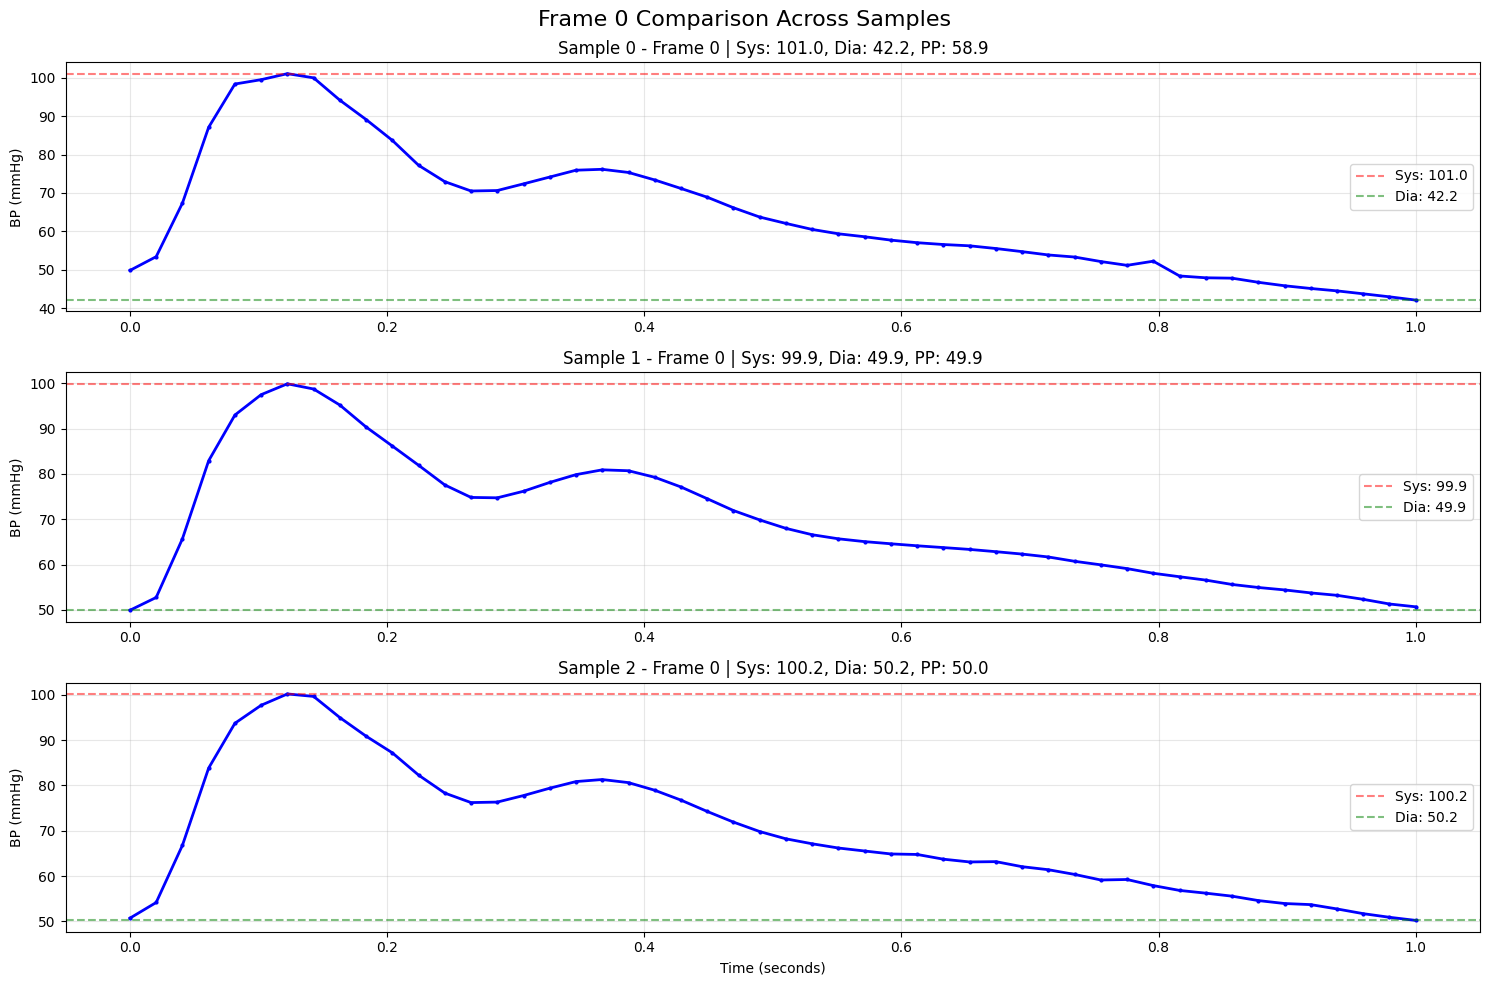

In [18]:
# Step 5: Compare frames across different samples
print("="*60)
print("STEP 5: Comparing Frames Across Samples")
print("="*60)

def compare_samples_frames(dataset, sample_indices=[0, 1, 2], frame_idx=0, figsize=(15, 10)):
    """Compare the same frame across different samples"""
    
    n_samples = len(sample_indices)
    fig, axes = plt.subplots(n_samples, 1, figsize=figsize)
    
    if n_samples == 1:
        axes = [axes]
    
    for i, sample_idx in enumerate(sample_indices):
        if sample_idx >= len(dataset):
            axes[i].text(0.5, 0.5, f'Sample {sample_idx} not available', 
                        ha='center', va='center', transform=axes[i].transAxes)
            continue
            
        sample = dataset[sample_idx]
        bp_signal = sample['bp']['signal']
        
        # Convert to numpy if tensor
        if isinstance(bp_signal, torch.Tensor):
            bp_signal = bp_signal.numpy()
        
        # Extract frame
        start_idx = frame_idx * FRAME_SIZE
        end_idx = start_idx + FRAME_SIZE
        
        if end_idx <= len(bp_signal):
            bp_frame = bp_signal[start_idx:end_idx]
            time_axis = np.linspace(0, 1, FRAME_SIZE)
            
            # Plot
            axes[i].plot(time_axis, bp_frame, 'b-', linewidth=2, marker='o', markersize=2)
            axes[i].grid(True, alpha=0.3)
            axes[i].set_ylabel('BP (mmHg)')
            
            # Statistics
            systolic = np.max(bp_frame)
            diastolic = np.min(bp_frame)
            
            # Add reference lines
            axes[i].axhline(y=systolic, color='red', linestyle='--', alpha=0.5, label=f'Sys: {systolic:.1f}')
            axes[i].axhline(y=diastolic, color='green', linestyle='--', alpha=0.5, label=f'Dia: {diastolic:.1f}')
            
            axes[i].set_title(f'Sample {sample_idx} - Frame {frame_idx} | Sys: {systolic:.1f}, Dia: {diastolic:.1f}, PP: {systolic-diastolic:.1f}')
            axes[i].legend()
            
            if i == len(sample_indices) - 1:  # Last subplot
                axes[i].set_xlabel('Time (seconds)')
        else:
            axes[i].text(0.5, 0.5, f'Frame {frame_idx} out of bounds', 
                        ha='center', va='center', transform=axes[i].transAxes)
    
    plt.suptitle(f'Frame {frame_idx} Comparison Across Samples', fontsize=16)
    plt.tight_layout()
    plt.show()

# Compare frame 0 across first 3 samples
if len(dataset) >= 3:
    compare_samples_frames(dataset, sample_indices=[0, 1, 2], frame_idx=0)
else:
    print(f"Dataset has only {len(dataset)} samples, showing available ones...")
    available_samples = list(range(min(3, len(dataset))))
    compare_samples_frames(dataset, sample_indices=available_samples, frame_idx=0)


STEP 6: Dataset-wide Frame Analysis
Analyzing frame 0 across 10 samples...

Frame 0 Statistics (n=10):
--------------------------------------------------
Systolic       :  104.1 ±   3.2 mmHg (range: 99.9-109.2)
Diastolic      :   51.8 ±   3.8 mmHg (range: 42.2-56.1)
Pulse Pressure :   52.3 ±   2.6 mmHg (range: 49.9-58.9)
Mean Bp        :   72.9 ±   4.0 mmHg (range: 64.6-78.0)
Std Bp         :   14.5 ±   0.8 mmHg (range: 13.6-16.4)


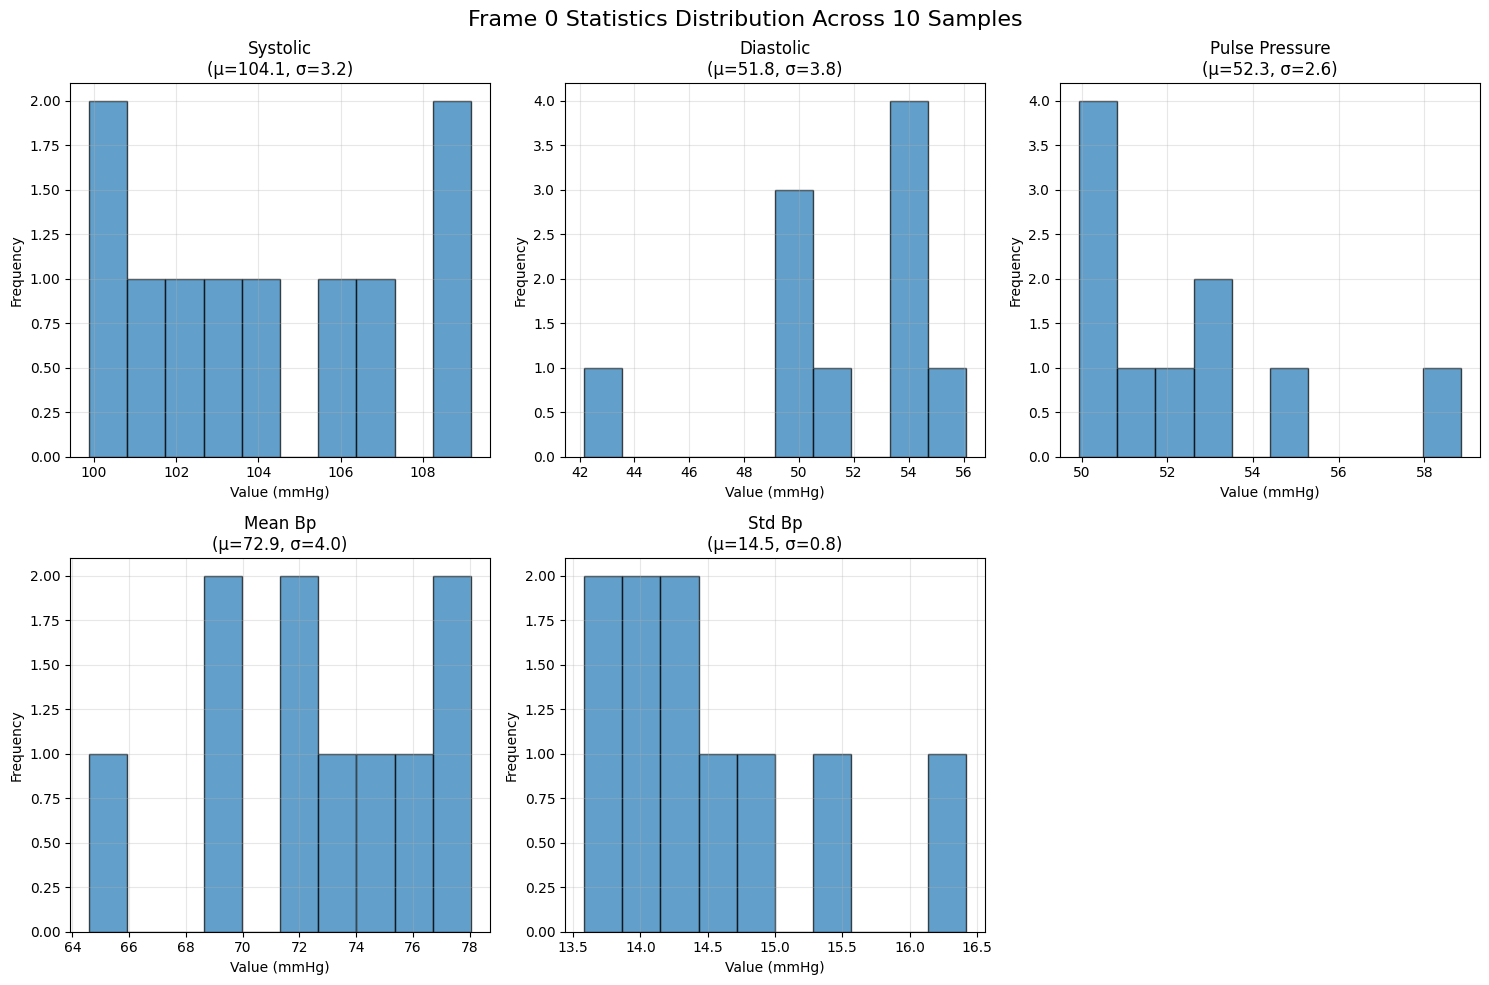

In [19]:
# Step 6: Advanced analysis - Frame statistics across the dataset
print("="*60)
print("STEP 6: Dataset-wide Frame Analysis")
print("="*60)

def analyze_dataset_frames(dataset, frame_idx=0, max_samples=10):
    """Analyze a specific frame across multiple samples in the dataset"""
    
    frame_stats = {
        'systolic': [],
        'diastolic': [],
        'pulse_pressure': [],
        'mean_bp': [],
        'std_bp': []
    }
    
    valid_samples = 0
    
    print(f"Analyzing frame {frame_idx} across {min(max_samples, len(dataset))} samples...")
    
    for sample_idx in range(min(max_samples, len(dataset))):
        sample = dataset[sample_idx]
        bp_signal = sample['bp']['signal']
        
        # Convert to numpy if tensor
        if isinstance(bp_signal, torch.Tensor):
            bp_signal = bp_signal.numpy()
        
        # Extract frame
        start_idx = frame_idx * FRAME_SIZE
        end_idx = start_idx + FRAME_SIZE
        
        if end_idx <= len(bp_signal):
            bp_frame = bp_signal[start_idx:end_idx]
            
            # Calculate statistics
            systolic = np.max(bp_frame)
            diastolic = np.min(bp_frame)
            pulse_pressure = systolic - diastolic
            mean_bp = np.mean(bp_frame)
            std_bp = np.std(bp_frame)
            
            frame_stats['systolic'].append(systolic)
            frame_stats['diastolic'].append(diastolic)
            frame_stats['pulse_pressure'].append(pulse_pressure)
            frame_stats['mean_bp'].append(mean_bp)
            frame_stats['std_bp'].append(std_bp)
            
            valid_samples += 1
    
    if valid_samples == 0:
        print(f"No valid samples found for frame {frame_idx}")
        return
    
    # Print summary statistics
    print(f"\nFrame {frame_idx} Statistics (n={valid_samples}):")
    print("-" * 50)
    
    for stat_name, values in frame_stats.items():
        if values:
            mean_val = np.mean(values)
            std_val = np.std(values)
            min_val = np.min(values)
            max_val = np.max(values)
            
            print(f"{stat_name.replace('_', ' ').title():<15}: {mean_val:6.1f} ± {std_val:5.1f} mmHg (range: {min_val:.1f}-{max_val:.1f})")
    
    # Create visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    stat_names = list(frame_stats.keys())
    for i, (stat_name, values) in enumerate(frame_stats.items()):
        if i < len(axes) and values:
            axes[i].hist(values, bins=10, alpha=0.7, edgecolor='black')
            axes[i].set_title(f'{stat_name.replace("_", " ").title()}\n(μ={np.mean(values):.1f}, σ={np.std(values):.1f})')
            axes[i].set_xlabel('Value (mmHg)')
            axes[i].set_ylabel('Frequency')
            axes[i].grid(True, alpha=0.3)
    
    # Hide extra subplot
    if len(axes) > len(frame_stats):
        axes[-1].set_visible(False)
    
    plt.suptitle(f'Frame {frame_idx} Statistics Distribution Across {valid_samples} Samples', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return frame_stats

# Analyze frame 0 across the dataset
frame_stats = analyze_dataset_frames(dataset, frame_idx=0, max_samples=min(10, len(dataset)))


In [20]:
# Step 7: Easy-to-use plotting functions for quick analysis
print("="*60)
print("STEP 7: Quick Analysis Functions")
print("="*60)

def quick_plot_frame(dataset, sample_idx=0, frame_idx=0):
    """Quick one-liner to plot a BP frame"""
    plot_bp_frame_from_dataset(dataset, sample_idx, frame_idx, figsize=(10, 5))

def quick_compare_frames(dataset, sample_idx=0, frame_list=[0, 1, 2, 3]):
    """Quick comparison of multiple frames from same sample"""
    plot_multiple_bp_frames_from_dataset(dataset, sample_idx, frame_list, figsize=(14, 8))

def quick_compare_samples(dataset, frame_idx=0, sample_list=[0, 1, 2]):
    """Quick comparison of same frame across samples"""
    compare_samples_frames(dataset, sample_list, frame_idx, figsize=(12, 8))

# Examples of quick usage
print("Quick examples:")
print("1. Single frame plot:")
quick_plot_frame(dataset, sample_idx=0, frame_idx=1)

print("\n2. Multiple frames from same sample:")
quick_compare_frames(dataset, sample_idx=0, frame_list=[0, 2, 4, 6])


STEP 7: Quick Analysis Functions
Quick examples:
1. Single frame plot:


NameError: name 'plot_bp_frame_from_dataset' is not defined